# MedFlow — Notebook de Patches v2
**DATASUS SP 2022–2023** | Correções e visualizações para apresentação

Patches aplicados neste notebook:
1. Decodificação de CIDs → nomes legíveis
2. Top municípios com nomes (IBGE já decodificado)
3. Série histórica IPH com fórmula correta (patient-days)
4. Ranking de regiões de saúde (top 10, substitui detalhe de 1 região)
5. Exemplo de storytelling com dados reais (Barueri)


## 0. Setup

In [7]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import calendar
from pathlib import Path

# Paleta MedFlow
NAVY  = '#0D1B2A'
AZUL  = '#2E86C1'
CORAL = '#E8604C'
VERDE = '#1ABC9C'
OURO  = '#D4AC0D'

PROC = Path('dados/processados')
FIG  = Path('figuras')
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi': 130,
})

# Carregar parquets já processados
sih      = pd.read_parquet(PROC / 'sih_sp_2022_2023_raw.parquet')
iph_hosp = pd.read_parquet(PROC / 'iph_por_hospital_mensal.parquet')
iph_mun  = pd.read_parquet(PROC / 'iph_por_municipio_mensal.parquet')
iph_reg  = pd.read_parquet(PROC / 'iph_por_regiao_mensal.parquet')

print(f'SIH      : {len(sih):,} linhas')
print(f'IPH hosp : {len(iph_hosp):,} linhas')
print(f'IPH mun  : {len(iph_mun):,} linhas')
print(f'IPH reg  : {len(iph_reg):,} linhas')


SIH      : 5,210,357 linhas
IPH hosp : 14,821 linhas
IPH mun  : 7,817 linhas
IPH reg  : 1,397 linhas


## 1. Decodificação de CIDs
Tabela manual para os top CIDs + download da tabela completa CID-10 como fallback.


In [8]:
# Mapeamento dos top CIDs (cobertura dos mais frequentes no SUS SP)
CID_NOMES = {
    'O800': 'Parto normal',
    'J189': 'Pneumonia não especificada',
    'Z302': 'Contracepção intrauterina (DIU)',
    'O809': 'Parto por cesariana',
    'I64':  'AVC não especificado',
    'N390': 'Infecção urinária',
    'I219': 'Infarto agudo do miocárdio',
    'J180': 'Broncopneumonia',
    'A419': 'Sepse não especificada',
    'I500': 'Insuficiência cardíaca',
    'I10':  'Hipertensão arterial',
    'J440': 'DPOC com infecção respiratória',
    'K802': 'Cálculo de vesícula biliar',
    'K359': 'Apendicite aguda',
    'N185': 'Doença renal crônica estágio 5',
    'C349': 'Câncer de pulmão',
    'J06':  'Infecção respiratória alta aguda',
    'R991': 'Outras causas mal definidas',
    'G819': 'Hemiplegia não especificada',
    'E119': 'Diabetes mellitus tipo 2',
    'K922': 'Hemorragia gastrointestinal',
    'C509': 'Câncer de mama',
    'J45':  'Asma',
    'N20':  'Cálculo renal',
    'I251': 'Doença aterosclerótica do coração',
    'Z515': 'Sessão de quimioterapia',
    'O342': 'Cesárea prévia',
    'P219': 'Asfixia perinatal',
    'J960': 'Insuficiência respiratória aguda',
    'Z514': 'Sessão de radioterapia',
}

def decode_cid(cid):
    cid = str(cid).strip().upper()
    return CID_NOMES.get(cid, cid)

# Aplicar no SIH
sih['diag_nome'] = sih['DIAG_PRINC'].astype(str).str.strip().str.upper().map(
    lambda c: CID_NOMES.get(c, c)
)

# Validar cobertura no top 10
top10_cids = (sih.groupby('DIAG_PRINC').size()
              .sort_values(ascending=False).head(10).index.tolist())
cobertura = sum(1 for c in top10_cids if c in CID_NOMES)
print(f'Cobertura do dicionário nos top 10 CIDs: {cobertura}/10')
for c in top10_cids:
    print(f'  {c:6} → {CID_NOMES.get(c, "[sem mapeamento]")}')


Cobertura do dicionário nos top 10 CIDs: 10/10
  O800   → Parto normal
  J189   → Pneumonia não especificada
  Z302   → Contracepção intrauterina (DIU)
  O809   → Parto por cesariana
  I64    → AVC não especificado
  N390   → Infecção urinária
  I219   → Infarto agudo do miocárdio
  J180   → Broncopneumonia
  A419   → Sepse não especificada
  I500   → Insuficiência cardíaca


## 2. Top 10 CIDs — Com Nomes Decodificados

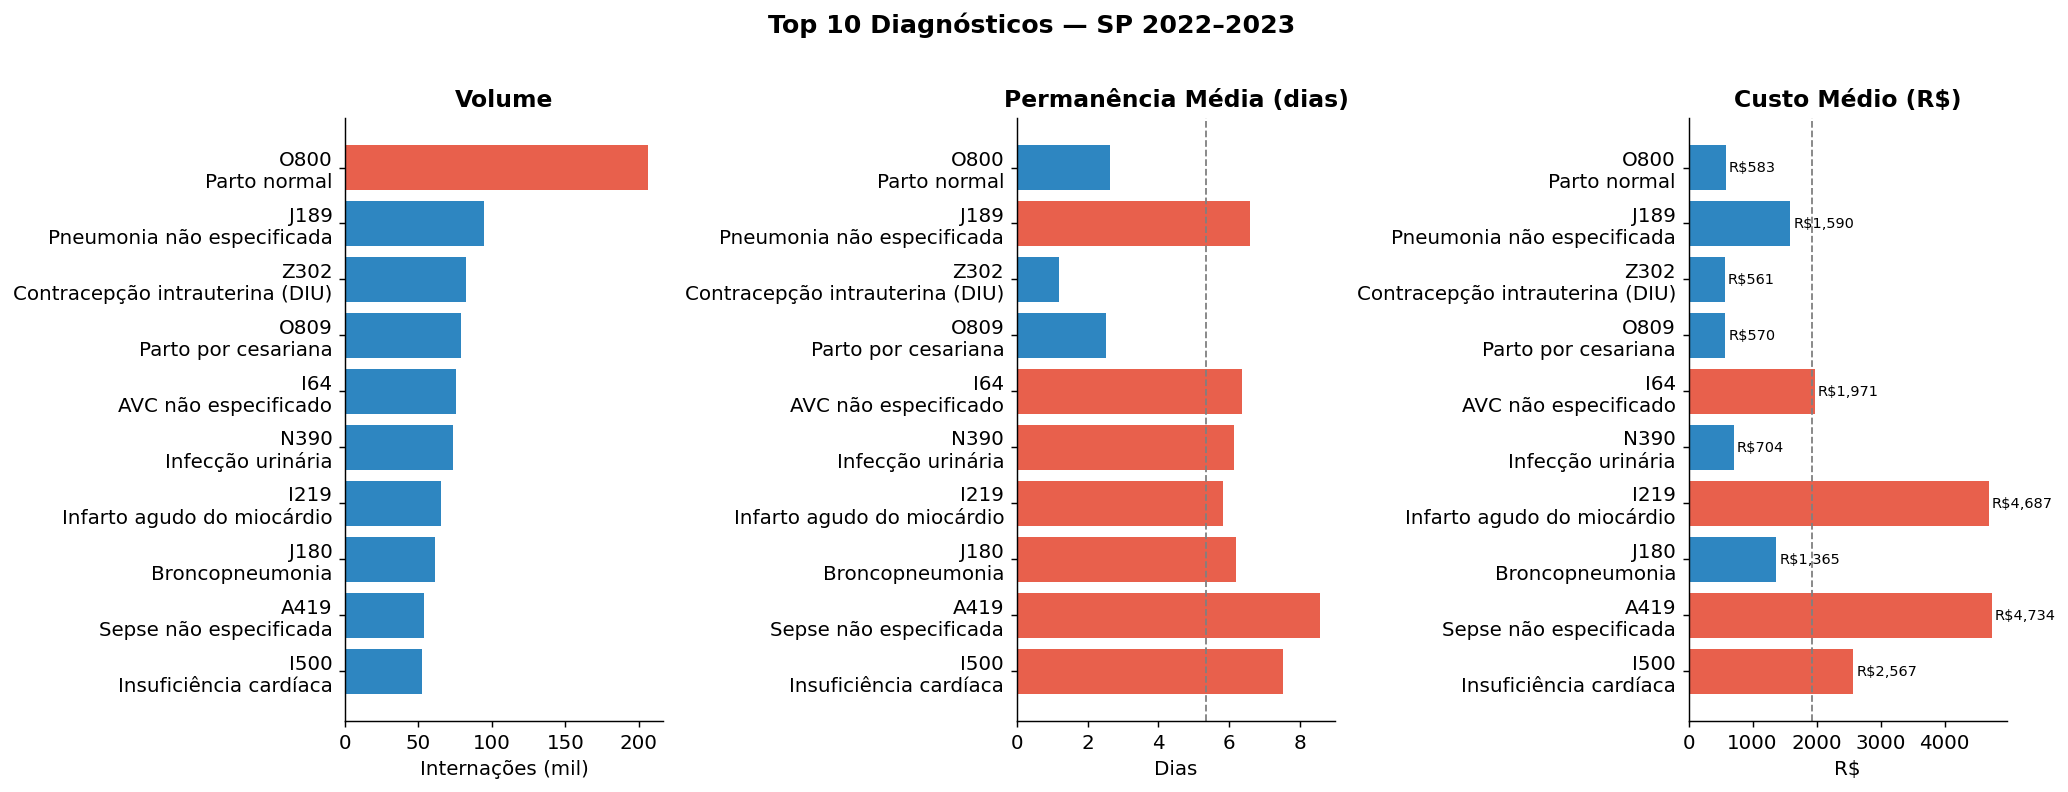

Salvo: P1_top10_cids_nomes.png
DIAG_PRINC                       diag_nome  internacoes  perm_media  custo_medio
      O800                    Parto normal       206376    2.629724   583.073964
      J189      Pneumonia não especificada        94797    6.580293  1589.744734
      Z302 Contracepção intrauterina (DIU)        82373    1.198572   561.037896
      O809             Parto por cesariana        79067    2.508101   570.078801
       I64            AVC não especificado        75458    6.369888  1970.820523
      N390               Infecção urinária        73591    6.152736   704.012827
      I219      Infarto agudo do miocárdio        65465    5.817078  4687.043084
      J180                 Broncopneumonia        61567    6.204103  1365.022584
      A419          Sepse não especificada        53457    8.572236  4734.463466
      I500          Insuficiência cardíaca        52612    7.518969  2566.781191


In [9]:
sih_clean = sih[sih['DIAG_PRINC'].astype(str).str.match(r'^[A-Z]\d')]
top_cids = (
    sih_clean.groupby(['DIAG_PRINC', 'diag_nome'])
    .agg(
        internacoes   = ('DIAG_PRINC', 'count'),
        perm_media    = ('QT_DIARIAS', lambda x: pd.to_numeric(x, errors='coerce').mean()),
        custo_medio   = ('VAL_TOT',    lambda x: pd.to_numeric(x, errors='coerce')[pd.to_numeric(x, errors='coerce') > 0].mean()),
    )
    .reset_index()
    .sort_values('internacoes', ascending=False)
    .head(10)
)
top_cids['label'] = top_cids.apply(
    lambda r: f"{r['DIAG_PRINC']}\n{r['diag_nome']}" if r['diag_nome'] != r['DIAG_PRINC'] else r['DIAG_PRINC'],
    axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Top 10 Diagnósticos — SP 2022–2023', fontsize=14, fontweight='bold', y=1.01)

# Volume
cores = [CORAL if i == 0 else AZUL for i in range(len(top_cids))]
axes[0].barh(top_cids['label'], top_cids['internacoes'] / 1000, color=cores)
axes[0].set_xlabel('Internações (mil)')
axes[0].set_title('Volume')
axes[0].invert_yaxis()

# Permanência média
cores_p = [CORAL if v > top_cids['perm_media'].mean() else AZUL for v in top_cids['perm_media']]
axes[1].barh(top_cids['label'], top_cids['perm_media'], color=cores_p)
axes[1].set_xlabel('Dias')
axes[1].axvline(top_cids['perm_media'].mean(), color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Permanência Média (dias)')
axes[1].invert_yaxis()

# Custo médio
cores_c = [CORAL if v > top_cids['custo_medio'].mean() else AZUL for v in top_cids['custo_medio']]
axes[2].barh(top_cids['label'], top_cids['custo_medio'], color=cores_c)
axes[2].set_xlabel('R$')
axes[2].axvline(top_cids['custo_medio'].mean(), color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Custo Médio (R$)')
for ax_i, val in enumerate(top_cids['custo_medio']):
    axes[2].text(val + 50, ax_i, f'R${val:,.0f}', va='center', fontsize=8)
axes[2].invert_yaxis()

plt.tight_layout()
fig.savefig(FIG / 'P1_top10_cids_nomes.png', bbox_inches='tight', dpi=130)
plt.show()
print('Salvo: P1_top10_cids_nomes.png')
print(top_cids[['DIAG_PRINC','diag_nome','internacoes','perm_media','custo_medio']].to_string(index=False))

## 3. Top 15 Municípios por IPH — Com Nomes

IBGE carregado: 645 municípios SP


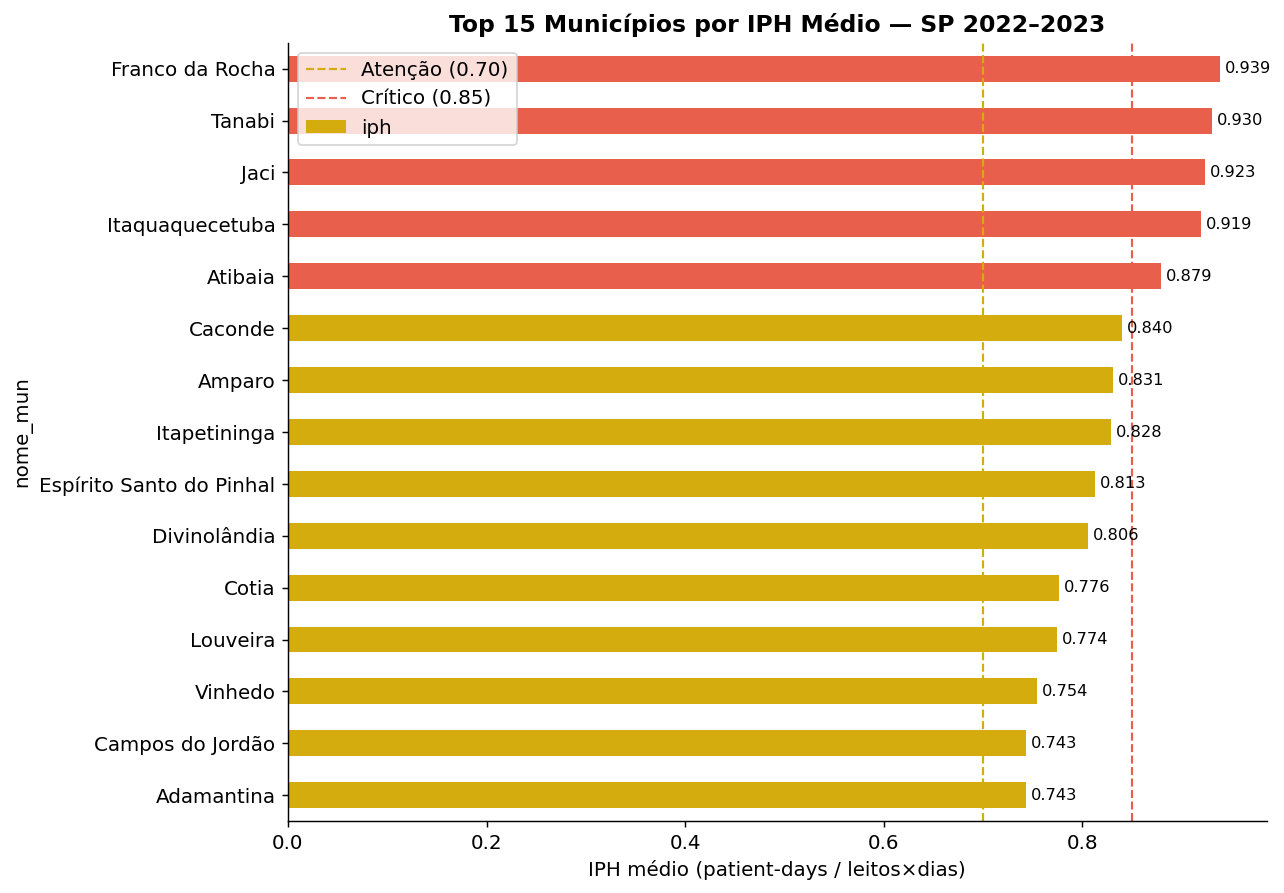

Salvo: P2_top15_municipios_nomes.png


In [10]:
import urllib.request

# Recarregar decode IBGE (já feito no notebook anterior, refazendo para ser autossuficiente)
URL_IBGE = 'https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv'
try:
    ibge = pd.read_csv(URL_IBGE, dtype=str)
    ibge_sp = ibge[ibge['codigo_ibge'].str.startswith('35')].copy()
    ibge_sp['munic_6'] = ibge_sp['codigo_ibge'].str[:6]
    decode_mun = dict(zip(ibge_sp['munic_6'], ibge_sp['nome']))
    print(f'IBGE carregado: {len(ibge_sp)} municípios SP')
except Exception as e:
    print(f'Fallback para dicionário manual: {e}')
    decode_mun = {
        '355030': 'São Paulo', '350950': 'Campinas', '354980': 'Santo André',
        '354340': 'Ribeirão Preto', '351880': 'Guarulhos', '355220': 'São Bernardo',
        '354780': 'Sorocaba', '354990': 'Santos', '352590': 'Mauá',
        '350570': 'Bauru', '354140': 'Piracicaba', '354870': 'São José dos Campos',
        '350600': 'Bauru', '354850': 'Santos', '353060': 'Mogi das Cruzes',
    }

# Adicionar nomes ao iph_mun
if 'municipio' in iph_mun.columns:
    iph_mun['nome_mun'] = iph_mun['municipio'].astype(str).map(decode_mun).fillna(iph_mun['municipio'].astype(str))
elif 'MUNIC_MOV' in iph_mun.columns:
    iph_mun['nome_mun'] = iph_mun['MUNIC_MOV'].astype(str).map(decode_mun).fillna(iph_mun['MUNIC_MOV'].astype(str))
else:
    # tentar coluna de municipio genérica
    mun_col = [c for c in iph_mun.columns if 'mun' in c.lower() or 'munic' in c.lower()][0]
    iph_mun['nome_mun'] = iph_mun[mun_col].astype(str).map(decode_mun).fillna(iph_mun[mun_col].astype(str))

iph_col = 'iph_medio' if 'iph_medio' in iph_mun.columns else 'iph'
top_mun = (iph_mun.groupby('nome_mun')[iph_col]
           .mean()
           .sort_values(ascending=False)
           .head(15))

cores_m = []
for v in top_mun:
    if v > 0.85: cores_m.append(CORAL)
    elif v > 0.70: cores_m.append(OURO)
    else: cores_m.append(AZUL)

fig, ax = plt.subplots(figsize=(10, 7))
top_mun.sort_values().plot(kind='barh', ax=ax, color=list(reversed(cores_m)))
ax.axvline(0.70, color=OURO,  linestyle='--', linewidth=1.2, label='Atenção (0.70)')
ax.axvline(0.85, color=CORAL, linestyle='--', linewidth=1.2, label='Crítico (0.85)')
ax.set_title('Top 15 Municípios por IPH Médio — SP 2022–2023')
ax.set_xlabel('IPH médio (patient-days / leitos×dias)')
ax.legend()
for i, (nome, val) in enumerate(top_mun.sort_values().items()):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIG / 'P2_top15_municipios_nomes.png', bbox_inches='tight', dpi=130)
plt.show()
print('Salvo: P2_top15_municipios_nomes.png')


## 4. Série Histórica IPH — Fórmula Correta (patient-days)

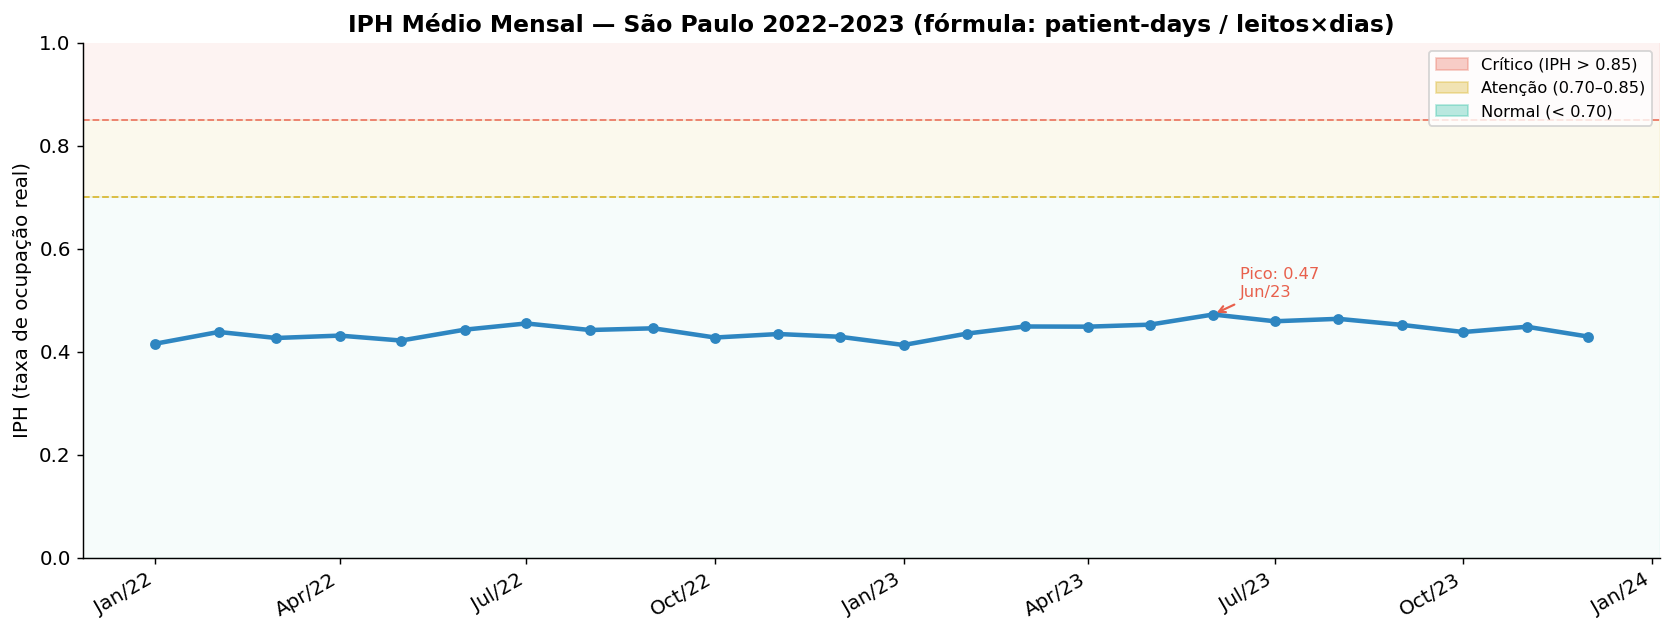

Mês com maior IPH médio: Jun/2023 -> IPH=0.472
Mês com menor IPH médio: Jan/2023 -> IPH=0.413
Amplitude: 0.059


In [11]:
# Usar iph_por_hospital_mensal.parquet que já foi recalculado com patient-days
iph_col = 'iph' if 'iph' in iph_hosp.columns else [c for c in iph_hosp.columns if 'iph' in c.lower()][0]

serie = (iph_hosp
         .groupby(['_ano', '_mes'])[iph_col]
         .mean()
         .reset_index())
serie['periodo'] = pd.to_datetime(
    serie['_ano'].astype(str) + '-' + serie['_mes'].astype(str).str.zfill(2) + '-01'
)
serie = serie.sort_values('periodo')

# Banda de sazonalidade por mês (média histórica ± std)
mes_stats = serie.groupby('_mes')[iph_col].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

# Faixas de criticidade
ax.axhspan(0.85, 1.2, alpha=0.07, color=CORAL,  label='Zona Crítica (>0.85)')
ax.axhspan(0.70, 0.85, alpha=0.07, color=OURO,  label='Zona Atenção (0.70–0.85)')
ax.axhspan(0,   0.70, alpha=0.04, color=VERDE, label='Zona Normal (<0.70)')

# Linha principal
ax.plot(serie['periodo'], serie[iph_col],
        marker='o', linewidth=2.5, color=AZUL, markersize=5, zorder=5)

# Linhas de threshold
ax.axhline(0.70, color=OURO,  linestyle='--', linewidth=1, alpha=0.8)
ax.axhline(0.85, color=CORAL, linestyle='--', linewidth=1, alpha=0.8)

# Anotar picos
pico = serie.loc[serie[iph_col].idxmax()]
ax.annotate(
    f"Pico: {pico[iph_col]:.2f}\n{pico['periodo'].strftime('%b/%y')}",
    xy=(pico['periodo'], pico[iph_col]),
    xytext=(15, 10), textcoords='offset points',
    fontsize=9, color=CORAL,
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.2)
)

ax.set_title('IPH Médio Mensal — São Paulo 2022–2023 (fórmula: patient-days / leitos×dias)')
ax.set_ylabel('IPH (taxa de ocupação real)')
ax.set_ylim(0, 1.0)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%y'))
fig.autofmt_xdate()

legend_patches = [
    mpatches.Patch(color=CORAL, alpha=0.3, label='Crítico (IPH > 0.85)'),
    mpatches.Patch(color=OURO,  alpha=0.3, label='Atenção (0.70–0.85)'),
    mpatches.Patch(color=VERDE, alpha=0.3, label='Normal (< 0.70)'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
fig.savefig(FIG / 'P3_iph_serie_historica_corrigida.png', bbox_inches='tight', dpi=130)
plt.show()

print('Mês com maior IPH médio:', pico['periodo'].strftime('%b/%Y'), f'-> IPH={pico[iph_col]:.3f}')
print('Mês com menor IPH médio:', serie.loc[serie[iph_col].idxmin(), 'periodo'].strftime('%b/%Y'),
      f'-> IPH={serie[iph_col].min():.3f}')
print(f'Amplitude: {serie[iph_col].max() - serie[iph_col].min():.3f}')

## 5. Ranking das Regiões de Saúde (substitui detalhe de 1 região)

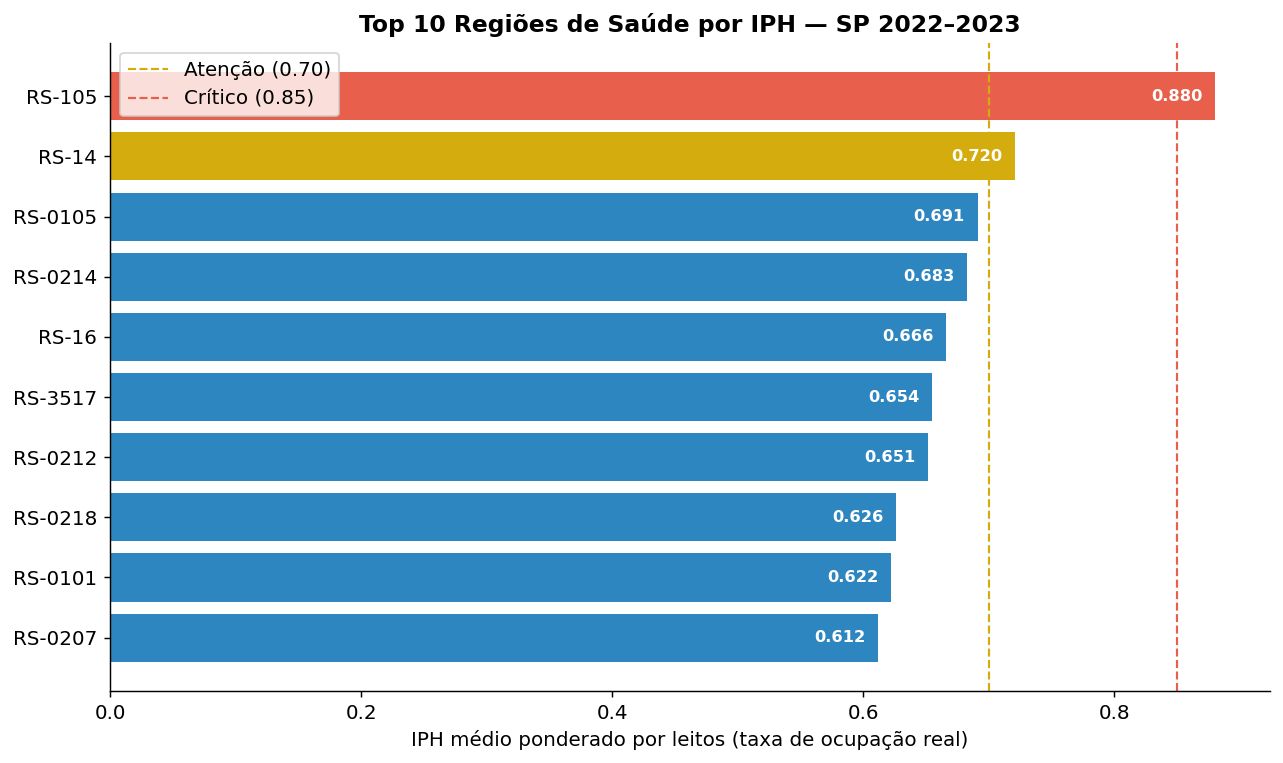

Top 10 regiões de saúde por IPH médio:
REGSAUDE  iph_medio   label
     105   0.879929  RS-105
      14   0.720457   RS-14
    0105   0.690902 RS-0105
    0214   0.682713 RS-0214
      16   0.665795   RS-16
    3517   0.654364 RS-3517
    0212   0.651146 RS-0212
    0218   0.625843 RS-0218
    0101   0.621877 RS-0101
    0207   0.611609 RS-0207


In [12]:
iph_col_r = 'iph_medio' if 'iph_medio' in iph_reg.columns else 'iph'
leitos_col = 'leitos_sus' if 'leitos_sus' in iph_reg.columns else None
reg_col = 'REGSAUDE' if 'REGSAUDE' in iph_reg.columns else iph_reg.columns[0]

# Agregar por região (média ponderada por leitos se disponível)
if leitos_col:
    reg_rank = (iph_reg[iph_reg[leitos_col] > 0]
                .groupby(reg_col)
                .apply(lambda g: np.average(g[iph_col_r].fillna(0),
                                            weights=g[leitos_col].clip(lower=1)),
                       include_groups=False)
                .reset_index(name='iph_medio')
                .sort_values('iph_medio', ascending=False)
                .head(10))
else:
    reg_rank = (iph_reg.groupby(reg_col)[iph_col_r]
                .mean().reset_index(name='iph_medio')
                .sort_values('iph_medio', ascending=False)
                .head(10))

reg_rank['label'] = 'RS-' + reg_rank[reg_col].astype(str)

cores_r = []
for v in reg_rank['iph_medio']:
    if v > 0.85:   cores_r.append(CORAL)
    elif v > 0.70: cores_r.append(OURO)
    else:          cores_r.append(AZUL)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(reg_rank['label'], reg_rank['iph_medio'], color=cores_r)
ax.axvline(0.70, color=OURO,  linestyle='--', linewidth=1.2, label='Atenção (0.70)')
ax.axvline(0.85, color=CORAL, linestyle='--', linewidth=1.2, label='Crítico (0.85)')
ax.set_title('Top 10 Regiões de Saúde por IPH — SP 2022–2023')
ax.set_xlabel('IPH médio ponderado por leitos (taxa de ocupação real)')
ax.invert_yaxis()
ax.legend()
for i, val in enumerate(reg_rank['iph_medio']):
    color = 'white' if val > 0.5 else 'black'
    ax.text(val - 0.01, i, f'{val:.3f}', va='center', ha='right', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
fig.savefig(FIG / 'P4_top10_regioes_saude.png', bbox_inches='tight', dpi=130)
plt.show()
print('Top 10 regiões de saúde por IPH médio:')
print(reg_rank.to_string(index=False))


## 6. Exemplo de Storytelling — 4 Camadas com Dados Reais
Demonstra o formato do MedFlow: número → contexto → padrão histórico → significado.  
Usa um hospital real com IPH crítico como caso de estudo.


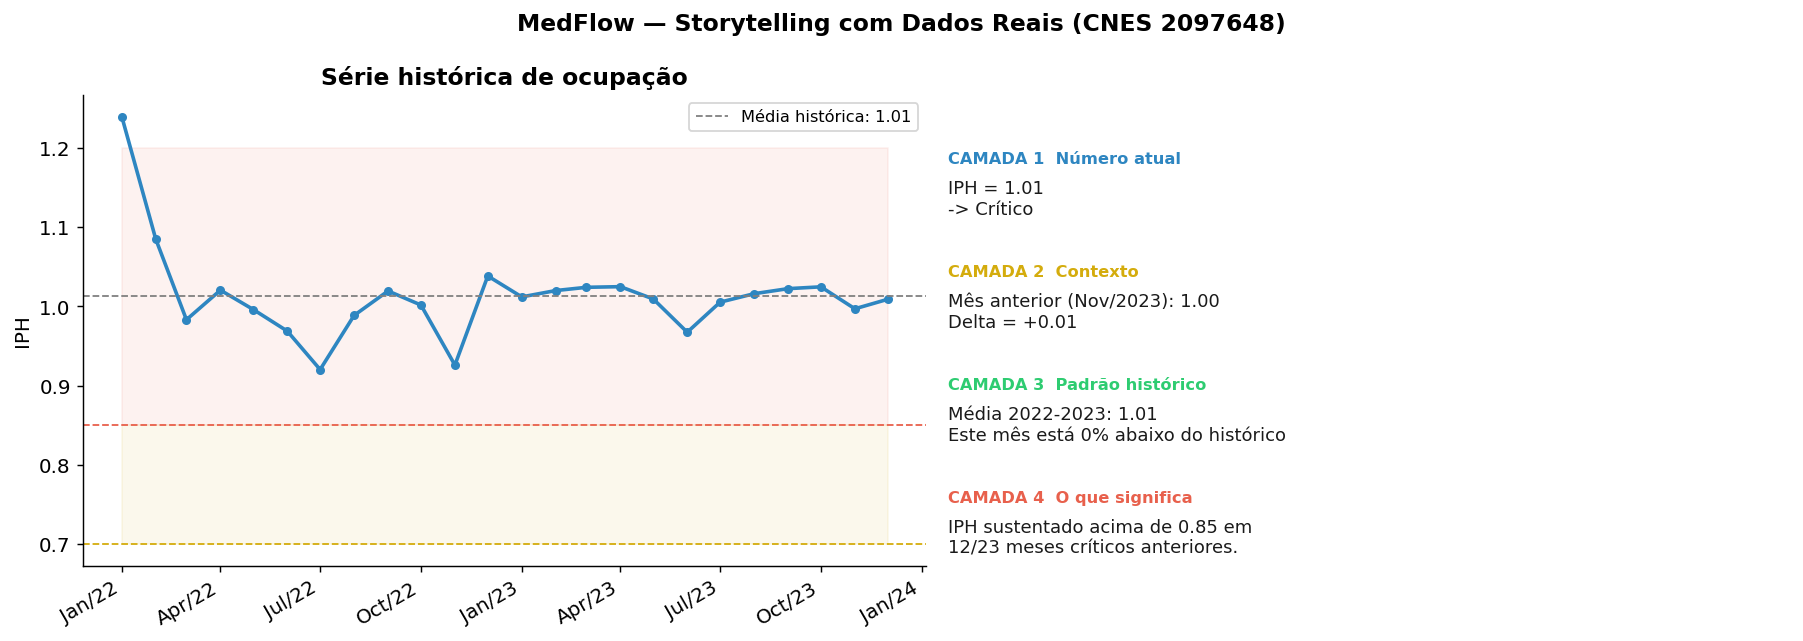

Hospital de exemplo: CNES 2097648
IPH mais recente: 1.009
Média histórica : 1.013
Meses de dados  : 24


In [13]:
# Identificar hospital com IPH mais interessante (crítico sustentado)
iph_col_h = 'iph' if 'iph' in iph_hosp.columns else [c for c in iph_hosp.columns if 'iph' in c.lower()][0]

hosp_stats = (iph_hosp
              .groupby('CNES')
              .agg(
                  iph_medio   = (iph_col_h, 'mean'),
                  iph_std     = (iph_col_h, 'std'),
                  n_meses     = (iph_col_h, 'count'),
                  internacoes = ('internacoes', 'sum') if 'internacoes' in iph_hosp.columns else (iph_col_h, 'count')
              )
              .query('n_meses >= 20')
              .sort_values('iph_medio', ascending=False))

cnes_caso = hosp_stats.index[0]
serie_caso = (iph_hosp[iph_hosp['CNES'] == cnes_caso]
              .sort_values(['_ano', '_mes'])
              .copy())
serie_caso['periodo'] = pd.to_datetime(
    serie_caso['_ano'].astype(str) + '-' + serie_caso['_mes'].astype(str).str.zfill(2) + '-01'
)

iph_atual    = serie_caso[iph_col_h].iloc[-1]
iph_med_hist = serie_caso[iph_col_h].mean()
mes_atual    = serie_caso['periodo'].iloc[-1].strftime('%b/%Y')
mes_ant      = serie_caso['periodo'].iloc[-2].strftime('%b/%Y')

# Contagem de meses críticos que sustentaram ou subiram
n_critic_mantido = sum(
    1 for i in range(1, len(serie_caso))
    if serie_caso[iph_col_h].iloc[i-1] > 0.85
    and serie_caso[iph_col_h].iloc[i] >= serie_caso[iph_col_h].iloc[i-1]
)
n_critic_total = sum(1 for v in serie_caso[iph_col_h].iloc[:-1] if v > 0.85)

status_atual = 'Crítico' if iph_atual > 0.85 else 'Atenção' if iph_atual > 0.70 else 'Normal'
delta = iph_atual - serie_caso[iph_col_h].iloc[-2]
pct_hist = abs(iph_atual / iph_med_hist - 1) * 100
dir_hist = 'acima' if iph_atual > iph_med_hist else 'abaixo'

# Plot storytelling de 4 camadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MedFlow — Storytelling com Dados Reais (CNES {cnes_caso})', fontsize=13, fontweight='bold')

# Esquerda: série histórica do hospital
ax = axes[0]
ax.fill_between(serie_caso['periodo'], 0.85, 1.2, alpha=0.08, color=CORAL)
ax.fill_between(serie_caso['periodo'], 0.70, 0.85, alpha=0.08, color=OURO)
ax.plot(serie_caso['periodo'], serie_caso[iph_col_h],
        marker='o', linewidth=2, color=AZUL, markersize=4)
ax.axhline(serie_caso[iph_col_h].mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Média histórica: {iph_med_hist:.2f}')
ax.axhline(0.85, color=CORAL, linestyle='--', linewidth=1)
ax.axhline(0.70, color=OURO,  linestyle='--', linewidth=1)
ax.set_title('Série histórica de ocupação')
ax.set_ylabel('IPH')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%y'))
fig.autofmt_xdate()

# Direita: as 4 camadas do storytelling
ax2 = axes[1]
ax2.axis('off')
layers = [
    ('CAMADA 1  Número atual',
     f'IPH = {iph_atual:.2f}\n-> {status_atual}'),
    ('CAMADA 2  Contexto',
     f'Mês anterior ({mes_ant}): {serie_caso[iph_col_h].iloc[-2]:.2f}\n'
     f'Delta = {delta:+.2f}'),
    ('CAMADA 3  Padrão histórico',
     f'Média 2022-2023: {iph_med_hist:.2f}\n'
     f'Este mês está {pct_hist:.0f}% {dir_hist} do histórico'),
    ('CAMADA 4  O que significa',
     f'IPH sustentado acima de 0.85 em\n'
     f'{n_critic_mantido}/{n_critic_total} meses críticos anteriores.'),
]
colors_l = [AZUL, OURO, '#2ECC71', CORAL]
for i, (titulo, texto) in enumerate(layers):
    y = 0.88 - i * 0.24
    ax2.text(0.0, y,       titulo, fontsize=9, fontweight='bold', color=colors_l[i], va='top')
    ax2.text(0.0, y - 0.06, texto, fontsize=10, va='top', color='#1a1a1a')

plt.tight_layout()
fig.savefig(FIG / 'P5_storytelling_exemplo.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Hospital de exemplo: CNES {cnes_caso}')
print(f'IPH mais recente: {iph_atual:.3f}')
print(f'Média histórica : {iph_med_hist:.3f}')
print(f'Meses de dados  : {len(serie_caso)}')

## 7. Card de Números-Chave — Versão Atualizada

In [14]:
# Recalcular com o iph recalculado
iph_col_h2 = 'iph' if 'iph' in iph_hosp.columns else [c for c in iph_hosp.columns if 'iph' in c.lower()][0]
dist_iph = iph_hosp[iph_col_h2].dropna()

pct_critico = (dist_iph > 0.85).mean() * 100
pct_atencao = ((dist_iph > 0.70) & (dist_iph <= 0.85)).mean() * 100
iph_medio   = dist_iph.mean()

# TMH geral
sih['MORTE'] = pd.to_numeric(sih['MORTE'], errors='coerce').fillna(0)
tmh_geral = sih['MORTE'].mean() * 100

# CID mais frequente
top1_cid  = sih['DIAG_PRINC'].value_counts().index[0]
top1_nome = CID_NOMES.get(str(top1_cid).strip().upper(), top1_cid)
top1_n    = sih['DIAG_PRINC'].value_counts().iloc[0]

# Custo
cmi_geral = pd.to_numeric(sih['VAL_TOT'], errors='coerce')
cmi_geral = cmi_geral[cmi_geral > 0].mean()

# Região mais crítica
iph_col_r2 = 'iph_medio' if 'iph_medio' in iph_reg.columns else 'iph'
reg_col2   = 'REGSAUDE' if 'REGSAUDE' in iph_reg.columns else iph_reg.columns[0]
top_reg    = iph_reg[iph_reg.get('leitos_sus', pd.Series([1]*len(iph_reg))) > 0].groupby(reg_col2)[iph_col_r2].mean().idxmax()
top_reg_v  = iph_reg[iph_reg.get('leitos_sus', pd.Series([1]*len(iph_reg))) > 0].groupby(reg_col2)[iph_col_r2].mean().max()

print()
print('╔' + '═'*55 + '╗')
print('║   MEDFLOW — NÚMEROS-CHAVE SP 2022–2023' + ' '*15 + '║')
print('╠' + '═'*55 + '╣')
print(f'║  Total internações              : {len(sih):>12,}   ║')
print(f'║  IPH médio geral (patient-days) : {iph_medio:>12.4f}   ║')
print(f'║  Hospitais status Crítico        : {pct_critico:>11.1f}%   ║')
print(f'║  Hospitais status Atenção        : {pct_atencao:>11.1f}%   ║')
print(f'║  TMH geral                       : {tmh_geral:>11.2f}%   ║')
print(f'║  CMI médio                       : R$ {cmi_geral:>9,.0f}   ║')
print('╠' + '═'*55 + '╣')
print(f'║  CID mais frequente              : {top1_cid:<6} ({top1_n:,})║')
print(f'║    → {top1_nome:<49}║')
print(f'║  REGSAUDE mais pressionada       : {str(top_reg):<6} (IPH {top_reg_v:.3f})║')
print('╚' + '═'*55 + '╝')

# Salvar CSV resumo
resumo = pd.DataFrame([{
    'total_internacoes': len(sih),
    'iph_medio': round(iph_medio, 4),
    'pct_critico': round(pct_critico, 1),
    'pct_atencao': round(pct_atencao, 1),
    'tmh_geral': round(tmh_geral, 2),
    'cmi_medio': round(cmi_geral, 2),
    'top_cid': top1_cid,
    'top_cid_nome': top1_nome,
    'top_cid_n': top1_n,
    'regsaude_top': top_reg,
    'regsaude_iph': round(top_reg_v, 3),
}])
resumo.to_csv(PROC / 'numeros_chave.csv', index=False)
print('\nSalvo: dados/processados/numeros_chave.csv')



╔═══════════════════════════════════════════════════════╗
║   MEDFLOW — NÚMEROS-CHAVE SP 2022–2023               ║
╠═══════════════════════════════════════════════════════╣
║  Total internações              :    5,210,357   ║
║  IPH médio geral (patient-days) :       0.4403   ║
║  Hospitais status Crítico        :         7.8%   ║
║  Hospitais status Atenção        :        10.5%   ║
║  TMH geral                       :        5.36%   ║
║  CMI médio                       : R$     1,670   ║
╠═══════════════════════════════════════════════════════╣
║  CID mais frequente              : O800   (206,376)║
║    → Parto normal                                     ║
║  REGSAUDE mais pressionada       : 105    (IPH 0.880)║
╚═══════════════════════════════════════════════════════╝

Salvo: dados/processados/numeros_chave.csv


---
## Outputs gerados

| Arquivo | Conteúdo |
|---|---|
| `figuras/P1_top10_cids_nomes.png` | Top 10 CIDs com nomes — volume, permanência e custo |
| `figuras/P2_top15_municipios_nomes.png` | Top 15 municípios por IPH com nomes IBGE |
| `figuras/P3_iph_serie_historica_corrigida.png` | IPH mensal com fórmula patient-days |
| `figuras/P4_top10_regioes_saude.png` | Ranking top 10 regiões de saúde |
| `figuras/P5_storytelling_exemplo.png` | Exemplo de storytelling com dados reais |
| `dados/processados/numeros_chave.csv` | Resumo dos KPIs principais |
